In [7]:
from IPython.display import display, Latex
from IPython.core.display import HTML
%reset -f
%matplotlib inline
%autosave 300

import matplotlib.pyplot as plt
import numpy as np

Autosaving every 300 seconds


# Un exemple convexe quadratique

On applique les différentes méthodes d'optimisation numérique vues en cours à un problème quadratique simple.

On veut résoudre numériquement le problème modèle suivant:
$$
(P) \qquad \inf \left\{ J(x):= \frac{1}{2} \left< A.x , x \right> - \left< b , x \right>
\, : \, x \in \mathbb{R}^3 \right\}
$$
où
$$
A := \begin{pmatrix}
1 & 4 & 3 \\
-3 & 6 & 3 \\
-1 & 0 & 7
\end{pmatrix}
\quad \quad et \quad \quad
b := \begin{pmatrix} -1 \\ 1 \\ -1 \end{pmatrix}.
$$


<b>1)</b> Montrer que $J$ est strictement convexe.
Ecrire les conditions d'optimalité et calculer la solution optimale théorique de $(P)$.

<i>Dans la suite, on pourra prendre comme test la distance à l'unique solution optimale de $(P)$.</i>


<span style="color:green">
   Vu en TD : la matrice hessienne de $J$ est
$$
D^2 J(x) = \frac{A+A^T}{2} = \frac{1}{2} \begin{pmatrix}
2 & 1 & 2 \\
1 & 12 & 3 \\
2 & 1 & 14
\end{pmatrix}
$$
dont les mineurs principaux sont strictement positifs. On peut aussi calculer les valeurs propres de cette matrice grâce à Python (question suivante), et vérifier qu'elles sont strictement positives.

Une solution $x^*$ du problème vérifie l'équation $\nabla J(x^*) = 0$, c'est-à-dire
$$ \frac{A+A^T}{2}.x^* = b $$
donc l'unique solution du problème est
$$x^* = \left(\frac{A+A^T}{2}\right)^{-1} .b$$
    </span>

<b>2)</b> Programmer la méthode de la plus grande pente à pas constant pour ce problème.

On prendra pour point initial $x^0 = 0$ et pour précision $\varepsilon = 10^{-2}$ (pour tester) et $\varepsilon=10^{-6}$.

On testera diverses valeurs pour le pas choisi et on comparera la vitesse de convergence
(c'est-à-dire le nombre d'itérations nécessaires avant l'arrêt de l'algorithme).


In [8]:
A=np.array([[1,4,3],[-3,6,3],[-1,0,7]])
b=np.array([-1,1,-1])

def J(x):
    return .5*np.dot(A @ x,x) - np.dot(b,x)

print(f'A={A},\n')

A=[[ 1  4  3]
 [-3  6  3]
 [-1  0  7]],



In [9]:
S=(A+A.T)/2

sol=np.linalg.solve(S,b)
print(f'la solution est {sol}')

vap=np.linalg.eig(S)[0]
vap=np.sort(vap)
print(f'les valeurs propres de S sont {vap}\n')

## fonctions pour le gradient de J

def gradJ(x):
    # calcul exact du gradient (pour cet exemple) :
    return S @ x -b

def gradJ_df(x):
    # calcul du gradient par différences finies (_df):
    gg=np.zeros(len(x))
    t=1e-14
    for i in range(len(x)):
        y=np.copy(x)
        y[i]+=t
        z=np.copy(x)
        z[i]-=t
        gg[i]=(J(y)-J(z))/(2*t)
    return gg

## Initialisation

x0=np.zeros(3)
delta=vap[0]/(vap[2]**2) # on prend le delta théorique !
print(delta)
#delta =0.2  # ceci est un meilleur delta !
epsilon = 1e-9

## Boucle principale pas constant

x=x0
cpt=0
g=gradJ_df(x)
while np.linalg.norm(g) > epsilon :
    x = x - delta * g
    g=gradJ_df(x)
    cpt += 1

print(f'on fait une erreur de {np.linalg.norm(x-sol)}')
print(f'en cpt={cpt} itérations')

la solution est [-1.08955224  0.26865672 -0.04477612]
les valeurs propres de S sont [0.82433445 4.92629863 8.24936691]

0.012113292663475522
on fait une erreur de 0.006702343778747936
en cpt=500 itérations


On peut aussi faire un travail un peu plus poussé, en traçant la précision obtenue en fonction du nombre d'itérations effectuées. La théorie dit que la convergence est linéraire, donc en échelle semi-logarithmique on devrait observer une droite.

la solution est [-1.08955224  0.26865672 -0.04477612]
les valeurs propres de S sont [0.82433445 4.92629863 8.24936691]



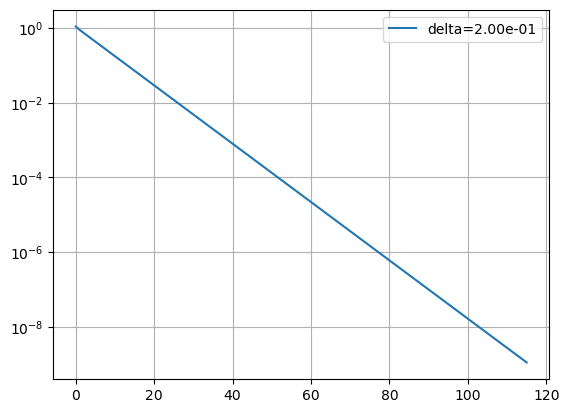

In [10]:
S=(A+A.T)/2

sol=np.linalg.solve(S,b)
print(f'la solution est {sol}')

vap=np.linalg.eig(S)[0]
print(f'les valeurs propres de S sont {np.sort(vap)}\n')

## Initialisation

x0=np.zeros(3)
#delta=vap[0]/(vap[2]**2) # on prend le delta théorique !
delta =0.2  # ceci est un meilleur delta !
epsilon = 1e-9

## Boucle principale pas constant

x=x0
cpt=0
g=gradJ(x)
precision=np.linalg.norm(x-sol)
precision_tab=[precision]
cpt_tab=[cpt]
while np.linalg.norm(g) > epsilon :
    x = x - delta * g
    g=gradJ(x)
    cpt += 1
    precision=np.linalg.norm(x-sol)
    precision_tab.append(precision)
    cpt_tab.append(cpt)

plt.semilogy(cpt_tab,precision_tab,label=(f'delta={delta:.2e}'))
plt.legend()
plt.grid()

<b>3)</b> Programmer la méthode de la plus grande pente à pas optimal pour ce problème. Pour cela, justifier que la solution du problème
$$
\min\left\{ j(t) = J\left(x-t \nabla J(x)\right) \,:\, t > 0 \right\}
$$
est
$$
\rho_{opt} = \frac{\langle \nabla J(x), \nabla J (x) \rangle}{\langle A. \nabla J(x), \nabla J (x) \rangle}.
$$


In [14]:
## Initialisation

x0=np.zeros(3)
epsilon = 1e-9

## Boucle principale pas optimal

x=x0
cpt=0
g=gradJ(x)
normg=np.linalg.norm(g)
while normg > epsilon :
    delta = np.dot(g,g) / np.dot(A @ g,g)
    x = x - delta * g
    g=gradJ_df(x)
    normg=np.linalg.norm(g)
    cpt += 1

print(f'on fait une erreur de {np.linalg.norm(x-sol)}')
print(f'en cpt={cpt} itérations')

[-0.25  0.25 -0.25] [ 0.62172489  0.         -0.62172489]
[-0.45724163  0.25       -0.04275837] [0.62727601 0.21094237 0.61617378]
[-0.56841455  0.21261442 -0.15196362] [ 0.38857806 -0.23314684 -0.31641356]
[-0.68010158  0.27962664 -0.06101846] [0.39968029 0.24424907 0.31086245]
[-0.75154471  0.23596695 -0.11658534] [ 0.24980018 -0.13322676 -0.2220446 ]
[-0.82206488  0.27357771 -0.05390075] [0.26090241 0.14988011 0.21094237]
[-0.86852056  0.2468904  -0.09146066] [ 0.17208457 -0.08881784 -0.13322676]
[-0.92268023  0.27484378 -0.0495306 ] [0.17208457 0.1110223  0.14432899]
[-0.95217424  0.25581538 -0.07426751] [ 0.09992007 -0.05551115 -0.09436896]
[-0.97890707  0.27066696 -0.04901983] [0.1110223  0.06106227 0.08326673]
[-0.99953024  0.25932422 -0.0644872 ] [ 0.06661338 -0.04440892 -0.06106227]
[-1.01666535  0.27074762 -0.04878002] [0.0721645  0.04440892 0.04996004]
[-1.03020158  0.26241763 -0.05815126] [ 0.03330669 -0.03330669 -0.03885781]
[-1.03690725  0.26912331 -0.05032797] [0.0499600

<span style="color:green">
    Attention : dans le code précédent, pour le pas optimal il vaut mieux utiliser la commande <b>np.dot(g,g)</b> (qui correspond à $\langle g,g \rangle$) plutôt que <b>normg**2</b> (qui est la norme de $g$ au carré) : mathématiquement les
    deux calculs sont les mêmes, mais numériquement l'erreur d'arrondi aboutit à une méthode qui ne converge pas !

On observe la convergence linéaire :

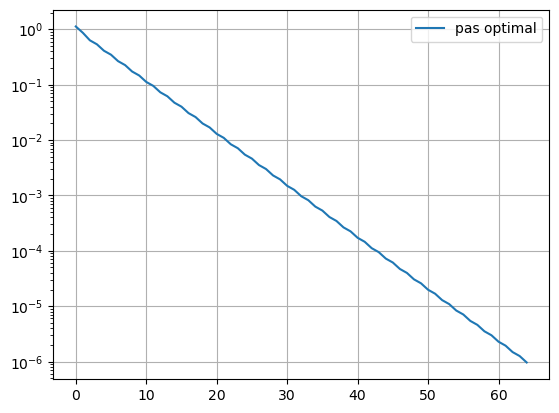

In [16]:
## Initialisation

x0=np.zeros(3)
epsilon = 1e-6

## Boucle principale pas optimal

x=x0
cpt=0
g=gradJ(x)
normg=np.linalg.norm(g)
precision=np.linalg.norm(x-sol)
precision_tab=[precision]
cpt_tab=[cpt]
while precision > epsilon :
    delta = np.dot(g,g) / np.dot(A @ g,g)
    x = x - delta * g
    g=gradJ(x)
    normg=np.linalg.norm(g)
    cpt += 1
    precision=np.linalg.norm(x-sol)
    precision_tab.append(precision)
    cpt_tab.append(cpt)

plt.semilogy(cpt_tab,precision_tab,label=('pas optimal'))
plt.legend()
plt.grid()

<b>4)</b> Programmer la méthode de la plus grande pente en utilisant
la recherche linéaire avec critère d'Armijo pour calculer le pas
à chaque étape.

Faire plusieurs essais selon les valeurs des paramètres $\alpha$ et
$c_1$ de cette recherche linéaire et comparer les vitesses
de convergence (nombre d'itérations pour chaque recherche linéaire,
et pour l'algorithme dans son ensemble).

In [17]:
def armijo(x,f,gradfx,alpha,m1):
    delta=alpha
    q = lambda t : f(x-t*gradfx)
    q0=q(0)
    qp0=-np.linalg.norm(gradfx)**2
    while q(delta) > q0+m1*qp0*delta :
        delta = delta/2
    return delta

## Initialisation

x0=np.zeros(3)
epsilon = 1e-7
alpha=.5
m1=.3

## Boucle principale pas optimal

x=x0
cpt=0
g=gradJ(x)
normg=np.linalg.norm(g)
while normg > epsilon :
    delta = armijo(x,J,g,alpha,m1)
    x = x - delta * g
    g=gradJ(x)
    normg=np.linalg.norm(g)
    cpt += 1

print(f'on fait une erreur de {np.linalg.norm(x-sol)}')
print(f'en cpt={cpt} itérations')


on fait une erreur de 1.0264734832201646e-07
en cpt=47 itérations


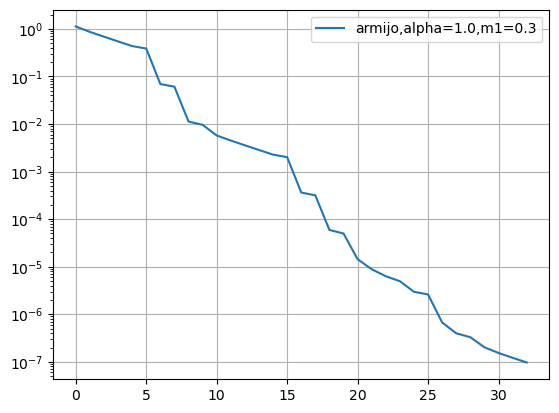

In [18]:
def armijo(x,f,gradfx,alpha,m1):
    delta=alpha
    q = lambda t : f(x-t*gradfx)
    q0=q(0)
    qp0=-np.linalg.norm(gradfx)**2
    while q(delta) > q0+m1*qp0*delta :
        delta = delta/2
    return delta

## Initialisation

x0=np.zeros(3)
epsilon = 1e-7
alpha=1.
m1=.3

## Boucle principale pas optimal

x=x0
cpt=0
g=gradJ(x)
normg=np.linalg.norm(g)
precision=np.linalg.norm(x-sol)
precision_tab=[precision]
cpt_tab=[cpt]
while precision > epsilon :
    delta = armijo(x,J,g,alpha,m1)
    x = x - delta * g
    g=gradJ(x)
    normg=np.linalg.norm(g)
    cpt += 1
    precision=np.linalg.norm(x-sol)
    precision_tab.append(precision)
    cpt_tab.append(cpt)

plt.semilogy(cpt_tab,precision_tab,label=(f'armijo,alpha={alpha},m1={m1}'))
plt.legend()
plt.grid()

<b>5)</b> Programmer la méthode prox : on rappelle que cela consiste,
à l'étape $n$, à résoudre de manière approchée le problème
$$
\inf\left\{ J(x) + \frac{1}{2\,\delta_n} \| x-x^n\|^2 \,:\, x \in \mathbb{R}^3 \right\}
$$
et à choisir pour $x^{n+1}$ la solution approchée trouvée.

Pour résoudre le problème d'optimisation apparaissant à chaque itération on choisira une méthode à pas constant ou avec recherche linéaire.

In [19]:
def methode_pas_constant(gradf,x0,delta,epsilon):
    x=x0
    cpt=0
    g=gradf(x)
    while np.linalg.norm(g) > epsilon :
        x = x - delta * g
        g=gradf(x)
        cpt += 1
    return [x,cpt]

## Initialisation

x0=np.zeros(3)
h=1.
epsilon=1e-12

## Boucle principale methode prox

x=x0
cpt=0
g=gradJ(x)
while np.linalg.norm(g) > epsilon :
    # on minimise J(z) + 1/(2h) |z-x|^2
    gradf= lambda z : gradJ(z) + (1/h)*(z-x)
    res=methode_pas_constant(gradf,x,h/10,epsilon/10)
    x = res[0]
    g=gradJ(x)
    cpt += 1

print(f'on fait une erreur de {np.linalg.norm(x-sol)}')
print(f'en cpt={cpt} itérations')

on fait une erreur de 1.165853218088644e-12
en cpt=46 itérations


<b>6)</b> Programmer la méthode de Newton pour ce problème.

In [20]:
## Initialisation

#x0=sol+0.1*np.random.rand(3,3)@sol  # on part d'un x0 proche de la solution
x0=np.zeros(3)
epsilon = 1e-7

print(sol, x0)

[-1.08955224  0.26865672 -0.04477612] [0. 0. 0.]


In [21]:
## Boucle principale méthode de Newton

x=x0
cpt=0
g=gradJ(x)
while np.linalg.norm(g) > epsilon :
    #D^2 J(x) = S pour tout x
    #y solution de : S.y = gradJ(x)
    y = np.linalg.solve(S,g)
    x = x - y
    g=gradJ(x)
    cpt += 1
    
print(f'on fait une erreur de {np.linalg.norm(x-sol)}')
print(f'en cpt={cpt} itérations')

on fait une erreur de 0.0
en cpt=1 itérations


<b>7)</b> Programmer la méthode de quasi-Newton BFGS pour ce problème, en employant une recherche linéaire avec le critère d'Armijo ou de Wolfe.

In [22]:
# fonction pour mettre à jour la matrice W
def bfgs(s,d,W):
    ss=np.reshape(s,(3,1))
    dd=np.reshape(d,(3,1))
    C=(ss @ np.transpose(dd))/np.vdot(ss,dd)
    A=W-(C @ W + W @ np.transpose(C))
    B=A+(np.vdot(W @ dd,dd)/np.vdot(ss,dd) +1) * ((ss @ np.transpose(ss))/np.vdot(ss,dd))
    return B

# adaptation de la méthode d'Armijo dans ce cas !
def armijo_bfgs(x,f,gradfx,Wg,alpha,c1): # (x,g,gg,c1_armijo,alpha_armijo):
    # attention, la recherche d'Armijo ici se fait pour la fonction t -> f(x+t W df(x))
    # donc la dérivée en t=0 est -gradf(x).(W gradf(x))
    delta=alpha
    q=lambda s:f(x-s*Wg)
    q0=q(0)
    qp0=-c1*np.dot(Wg,gradfx)
    cptarmijo=0
    while q(delta)>q0+qp0*delta:
        delta = delta/2
        cptarmijo+=1
    return [delta,cptarmijo]

## Initialisation

x0=np.zeros(3)
W=np.eye(3)

alpha=1.
c1=.2

epsilon = 1e-9

## Boucle principale

x=x0
cpt=0
g=gradJ(x)
while np.linalg.norm(g) > epsilon :
    Wg = W @ g
    result=armijo_bfgs(x,J,g,Wg,alpha,c1)
    delta=result[0]
    xnew = x - delta * Wg
    gnew=gradJ(xnew)
    cpt += 1
    s=xnew-x
    d=gnew-g
    W=bfgs(s,d,W)
    x=xnew
    g=gnew

    
print(f'on fait une erreur de {np.linalg.norm(x-sol)}')
print(f'en cpt={cpt} itérations')

on fait une erreur de 1.2724461751461428e-10
en cpt=5 itérations


Pour la recherche linéaire de Wolfe, on utilise la fonction <b>line_search</b> de scipy.

In [23]:
def bfgs(s,d,W):
    ss=np.reshape(s,(3,1))
    dd=np.reshape(d,(3,1))
    C=(ss @ np.transpose(dd))/np.vdot(ss,dd)
    A=W-(C @ W + W @ np.transpose(C))
    B=A+(np.vdot(W @ dd,dd)/np.vdot(ss,dd) +1) * ((ss @ np.transpose(ss))/np.vdot(ss,dd))
    return B

## chargement de line_search pour la méthode de Wolfe

from scipy.optimize import line_search

## Initialisation

x0=np.array([-1.,0.1,0.])
W=np.eye(3)

epsilon = 1e-9

## Boucle principale

x=x0
cpt=0
g=gradJ(x)
while np.linalg.norm(g) > epsilon :
    Wg=W@g
    result=line_search(J,gradJ,x,-Wg,c1=.2,c2=.8)
    delta=result[0]
    xnew = x - delta * Wg
    gnew=gradJ(xnew)
    cpt += 1
    s=xnew-x
    d=gnew-g
    if (cpt % 5) == 0:
        W=np.eye(3)
    else:
        W=bfgs(s,d,W)
    x=xnew
    g=gnew

    
print(f'on fait une erreur de {np.linalg.norm(x-sol)}')
print(f'en cpt={cpt} itérations')

on fait une erreur de 2.0816681711721685e-17
en cpt=4 itérations


# La fonction de Rosenbrock

Reprendre ce qui précède pour la fonction de Rosenbrock :
$$
f(x_1,x_2) = (x_2-x_1^2)^2+(x_1-1)^2
$$
On prendra différents points initiaux $x^0$ (par exemple $(0,0),\ldots$). 

1) On programme d'abord la méthode du gradient à pas constant :

In [24]:
def gradf(x):
    x1=x[0]
    x2=x[1]
    return np.array([4*x1*(x1**2-x2)+2*(x1-1) , 2*(x2-x1**2) ])

def funcf(x):
    x1=x[0]
    x2=x[1]
    return (x2-x1**2)**2+(x1-1)**2
def gradf_df(x):
    # calcul du gradient par différences finies (_df):
    gg=np.zeros(len(x))
    t=1e-12
    for i in range(len(x)):
        y=np.copy(x)
        y[i]+=t
        z=np.copy(x)
        z[i]-=t
        gg[i]=(funcf(y)-funcf(z))/(2*t)
    return gg

sol=np.array([1.,1.])
res=methode_pas_constant(gradf_df,np.zeros(2),1.e-1,1e-9)

print(f'on fait une erreur de {np.linalg.norm(res[0]-sol)}')
print(f'en cpt={res[1]} itérations')

on fait une erreur de 2.881695210713225e-09
en cpt=556 itérations


2) On programme la méthode du gradient à pas optimal :

In [27]:
# Calcul du delta optimal

def armijo(t,phi,gradphit,alpha,m1):
    delta=alpha
    q = lambda s : phi(x-t*gradphit)
    q0=q(0)
    qp0=-np.linalg.norm(gradfx)**2
    while q(delta) > q0+m1*qp0*delta :
        delta = delta/2
    return delta

def delta_opt(t,x,g,precision):
    q = lambda s : funcf(x-s*g)
    qprime = lambda s : -np.dot(gradf(x-s*g),g)
    t0=t
    alpha=1.
    m1=.5
    while abs(qprime(t))>precision:
        # armijo pour trouver le pas delta_t
        delta=alpha
        gqt = qprime(t)
        qt = lambda s : q(t-s*gqt)
        q0=qt(0)
        qtp0 = - gqt**2
        while qt(delta) > q0+m1*qtp0*delta:
            delta=delta/2
        t=t-delta*qprime(t)
    return t
    

x0=np.zeros(2)
x0=[.9,.9]
epsilon=1.e-9

# Boucle principale pas optimal

x=x0
cpt=0
g=gradf(x)
normg=np.linalg.norm(g)
delta=1
while normg > epsilon :
    delta = delta_opt(delta,x,g,1e-6)
    x = x - delta * g
    g=gradf_df(x)
    normg=np.linalg.norm(g)
    cpt += 1
    
print(f'solution trouvée={x},cpt={cpt}')

solution trouvée=[1. 1.],cpt=450


3) On programme la méthode d'Armijo.

In [29]:
def armijo(x,f,gradfx,alpha,m1):
    delta=alpha
    q = lambda t : f(x-t*gradfx)
    q0=q(0)
    qp0=-np.linalg.norm(gradfx)**2
    while q(delta) > q0+m1*qp0*delta :
        delta = delta/2
    return delta

# initialisation

x0=np.zeros(2)
#x0=[2,2]
epsilon=1.e-9
alpha = 1.
m1 =.5

# Boucle principale pas optimal

x=x0
cpt=0
g=gradf(x)
normg=np.linalg.norm(g)
while normg > epsilon :
    delta = armijo(x,funcf,g,alpha,m1)
    x = x - delta * g
    g=gradf_df(x)
    normg=np.linalg.norm(g)
    cpt += 1
    
print(f'on fait une erreur de {np.linalg.norm(x-sol)}')
print(f'en cpt={cpt} itérations')

on fait une erreur de 2.355261902850811e-09
en cpt=275 itérations
